In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os 
from pathlib import Path
import torch 

import m2aia as m2
from ims_contrastive_model import IMSPyTorchDataset, IMSContrastiveModel 
from ims_contrastive_model.utils.Binners import LinearBinning, NotEmptyInverseBinner, TopPeaksInverseBinner

# seting global dir
cwd=Path.cwd()
if cwd.name == "tutorials":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent) 
os.getcwd()

'/home/maxi7524/repositories/pym2aia_test'

## Introduction

In this tutorial we are going to: 
1. train `IMSContrastiveModel`, 
2. plot training results,
3. compress `imzML` image to latent space in `npz` format using `IMSContrastiveModel`,
4. load **only** latent space

## 1. Training IMSContrastiveModel

In [ ]:
# download prepare data and pretrained_model
!bash scripts/download/download.sh

We need to load imzML image, to do so we use `m2aia` loader and preprocessing tools.

TODO - cite ???

In [2]:
# data loading 
PATH_DATA = Path('data')
PATH_real_data = PATH_DATA / 'bladder_data' / 'mouse_urinary_bladder.imzML'
print(PATH_real_data.exists())

# load data - IMPORTANT (NEED TO PASS STR)
I = m2.ImzMLReader(
    str(PATH_real_data),
    # We assume tic normalization
    normalization=m2.m2NormalizationTIC
)

True
!Mon May  4 18:56:33 2026 
5.605! WARNING: No pixel size found, set x and y spacing to 50 microns!
!10.110! WARNING: Processed profile spectrum is not fully supported! Check the ImzML file.
[11.370] [imzML]: data/bladder_data/mouse_urinary_bladder.imzML
	[pixel size (mm)]: 0.050000x0.050000x0.010000
	[image dimension]: 260x134x1
	[num spectra]: 34840
	[spec. type]: ProcessedProfile
	[mass range]: 400.259620 to 999.795899 with #1500 measurements
	[normalization]: TIC


To initialize model we do as following steps
- create model instance object (contains path for model folder which stores its parameters)
- create model by:
  - creating new model by `define_model` method
  - loading existing model by `load` method (it takes initialization path)

In [3]:
# instantiation model|
model_path = PATH_DATA / 'bladder_data' / 'model'
model = IMSContrastiveModel(path=model_path, epochs=3)

Model will be loaded on cuda


In [15]:
# create new model

# creating dataset
# TODO this name is misleading - it is formally dataset
xs_res = I.GetSpacing()[2]
## i round values to max spacing to obtain 'nice' numbers, and i want to consider first and last numbers
xs_min = np.round(I.GetXAxis()[0] - xs_res, int(- np.log10(xs_res)))
xs_max = np.round(I.GetXAxis()[-1] + xs_res, int(- np.log10(xs_res)))
Binner = LinearBinning(
    xs_min=np.round(I.GetXAxis()[0]),
    xs_max=np.ceil(I.GetXAxis()[-1]),
    xs_res=xs_res,
)
# REMARKS - it can be unusable if model is not decoding well enough
# InverseBinner = NotEmptyInverseBinner(Binner)
InverseBinner = TopPeaksInverseBinner(Binner, max_bins=1500)

loader = IMSPyTorchDataset(m2aia_img=I, Binner=Binner)
model.define_model(latent_dim=64, IMSLoader=loader, InverseBinner=InverseBinner)

[IMSContrastiveModel]: Initialization of new model ... 


To train model we run `fit` method
- we can change save path, by default it takes path from `IMSPyTorchDataset` class instance

Our model will save parameters both:
- best: `model_weights.pt` file
- latest: `model_latest.pt` file

In [16]:
model.fit()

[fit]: New best model!
[fit]: Model is saved
Epoch 1/3 | Loss: 0.2072 | Patience: 0/5
[fit]: New best model!
[fit]: Model is saved
Epoch 2/3 | Loss: 0.0902 | Patience: 0/5
[fit]: New best model!
[fit]: Model is saved
Epoch 3/3 | Loss: 0.0863 | Patience: 0/5


In [4]:
# after training we load parameters for which model obtain best results
model.load()

[Load]: Model loaded successfully from data/bladder_data/model


## 2. Compress

To compress file we just run compress data. For convenience we also export there our model

In [13]:
path_compress = PATH_DATA / 'compressed_bladder_data_test'

# compress image
## IMPORTANT: if file with that name exists it will raise error
model.compress_to_file(path_compress / 'mouse_bladder_compressed.npz')
# save model
model.save(path_compress / 'model')

[Model] Encoding image to latent space...
[Model] Done encoding image.
[Model] Compression complete. Saved to: data/compressed_bladder_data_test/mouse_bladder_compressed.npz


## 3. Plot training results

To plot training results you can use `history` attribute or predefined methods.

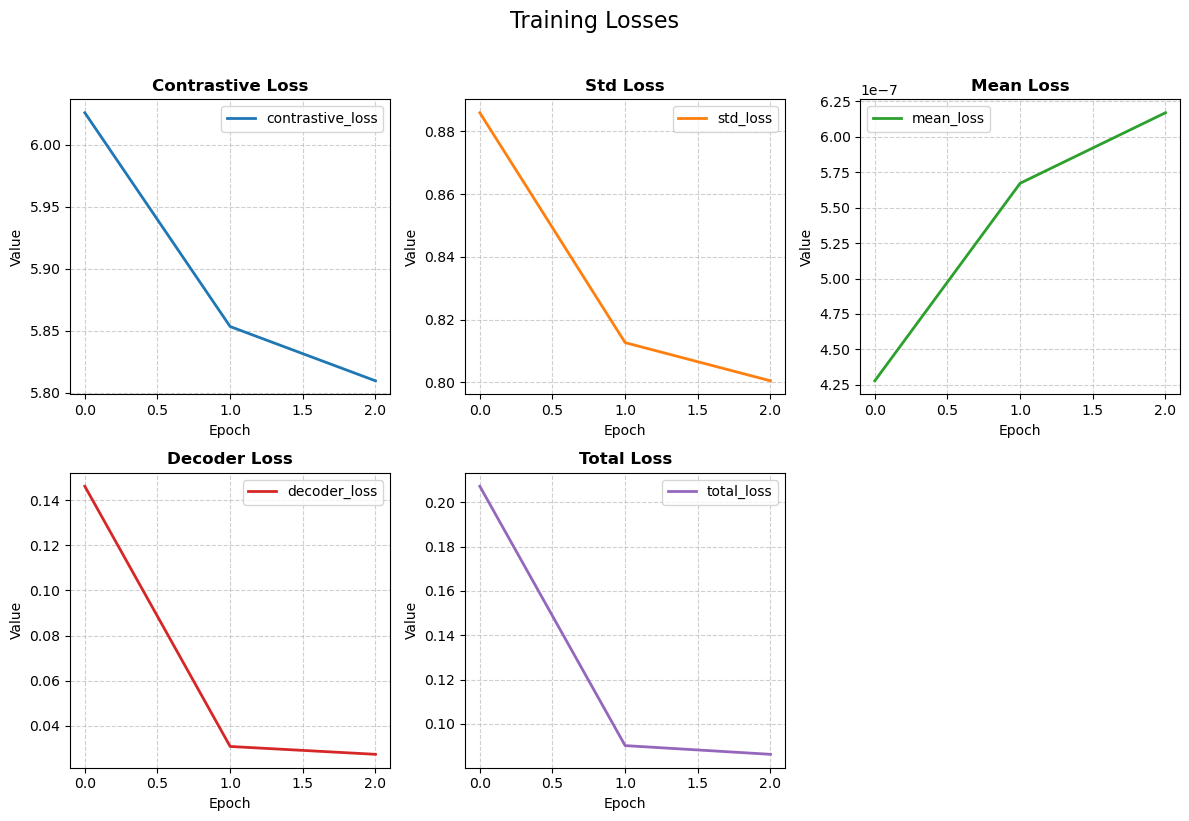

In [24]:
model.plot_epoch_losses()

## 4. Load latent space

You can obtain latent space on two ways:
- encode it, using `transform` method (IMPORTANT: `IMSPyTorchDataset` need to be connected)
- load it from compressed file 

In [11]:
# To obtain latent space in format (spectrum_id X latent) we run
latent_space = model.transform()
latent_space.shape

[Model] Encoding image to latent space...
[Model] Done encoding image.


(34840, 64)

In [14]:
# More convenient way is to use spatial coordinates, to obtain it we use
# case: we do not posses transform data
model.get_latent_grid().shape

[Model] Transforming current image to latent space...
[Model] Encoding image to latent space...


[Model] Done encoding image.


(260, 134, 1, 64)

In [12]:
# If we have already latent space
model.get_latent_grid(
    embeddings=latent_space, 
    coordinates=np.array([I.GetSpectrumPosition(i) for i in range(I.GetNumberOfSpectra())])
).shape

(260, 134, 1, 64)

In [9]:
# If our latent space is in file
model.get_latent_grid(
    compressed_path=path_compress / 'mouse_bladder_compressed.npz'
).shape

[Model] Loading latent space from data/compressed_bladder_data/mouse_bladder_compressed.npz...


(260, 134, 1, 64)

In [10]:
# or if we do not instantiated model
from ims_contrastive_model.utils.LatentSpace import build_latent_grid

data = np.load(path_compress / 'mouse_bladder_compressed.npz', allow_pickle=True)
embeddings = data['embeddings'] # Those are (spectrum_id X latent) format
coordinates = data['coordinates'] # Here are saved coordinates from image
build_latent_grid(embeddings, coordinates).shape

(260, 134, 1, 64)